# Licenciatura en Ciencia de Datos
## Calidad y Preprocesamiento de Datos

---

### **Proyecto Final — Perfilado de Datos**

**Equipo**

**Castrillo Cruz Karen Arlet**

**Pérez Aguiar Oropeza Gabriel Emiliano**

**Ramos González Nadia**

**Rueda Reyes Fabián**

**Torres Pasión Angel Isaac**


### **Objetivo**

Análisis exploratorio de los datos crudos de INE (Registro Nacional de Personas Sancionadas) y BANAVIM (Base Nacional sobre Violencia contra la Mujer), antes de cualquier transformación. Este notebook es autónomo y no requiere haber ejecutado ningún otro notebook previamente.


## 0. Ingesta de Datos


In [1]:
# Instalación de dependencias
!pip install unidecode openpyxl --quiet


In [2]:
import pandas as pd
import numpy as np
import re
import pickle
from pathlib import Path
from unicodedata import normalize
from unidecode import unidecode

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

print('Entorno listo')


Entorno listo


In [3]:
# Rutas base — funciona en Windows y Linux/macOS
DATA_DIR = Path('..') / 'Data'
PKL_DIR  = Path('.')   # los pkl viven en el mismo directorio que el notebook

DATA_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'fusion_outputs').mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR.resolve())
print('PKL_DIR :', PKL_DIR.resolve())


DATA_DIR: /home/emi/Desktop/Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores/Data
PKL_DIR : /home/emi/Desktop/Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores/Código


In [4]:
# 0.1 INE — Registro Nacional de Personas Sancionadas
df_ine_raw = pd.read_excel(
    DATA_DIR / 'Registro-nacional-de-personas-sancionadas (INE).xlsx'
)
df_ine_raw.columns = df_ine_raw.columns.str.strip()
print(f'INE crudo: {df_ine_raw.shape}')

# 0.2 BANAVIM — desde pkl pregenerados para evitar parsear los Excel originales
def leer_banavim_agresores(path: Path, año: int) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=f'AGRESORES {año}', header=0)
    df.columns = df.iloc[0]
    df = df.drop(index=0).reset_index(drop=True)
    df.columns = df.columns.str.strip()
    df['año_base'] = año
    return df

# bv_2020 = leer_banavim_agresores(DATA_DIR / '2020.xlsx', 2020)
# bv_2021 = leer_banavim_agresores(DATA_DIR / '2021.xlsx', 2021)
# bv_2022 = leer_banavim_agresores(DATA_DIR / '2022.xlsx', 2022)

for año in [2020, 2021, 2022]:
    with open(PKL_DIR / f'bv_{año}.pkl', 'rb') as f:
        globals()[f'bv_{año}'] = pickle.load(f)
    print(f'BANAVIM {año}: {globals()[f"bv_{año}"].shape}')


INE crudo: (530, 25)
BANAVIM 2020: (265760, 28)
BANAVIM 2021: (285984, 28)
BANAVIM 2022: (254348, 28)


In [5]:
# Vista previa
print('INE (últimas 5 filas)')
display(df_ine_raw.tail(5))
print('BANAVIM 2020 (primeras 3 filas)')
display(bv_2020.head(3))

INE (últimas 5 filas)


,Nombre,"Calidad, cargo o profesión del sujeto infractor",Sexo,Ámbito Territorial,Entidad Federativa,Municipio,Número De Expediente,Relación Con La Víctima,Incidencia,Órgano Resolutor,Fecha De La Resolución,Conducta,Sanción,Permanencia,Reincidencia De La Conducta,Resolución Penal,Analizó Modo Honesto De Vivir,Cumple Modo Honesto De Vivir,Perteneciente a,Documento Enlace,Enlace Utce Temporalidad,Interseccion de la víctima,Tipo de violencia,Modalidad de violencia,Medidas de reparacion
525,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,JDC/133/2020,Pares,No aplica,TE,11/06/2021,"Negativa a restituir a la víctima en el pleno goce de sus derechos políticos electorales, al omi...",Ninguna,29/09/2027,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/131519/JDC-133-2020-TEEO.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Medidas de no repetición</e..."
526,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,JDC/143/2020,Pares,No aplica,TE,11/06/2021,Omisión de pago de dietas a la víctima y de convocarla a sesiones de cabildo,Ninguna,29/09/2027,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/131520/JDC-143-2020-TEEO.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Medidas de no repetición</e..."
527,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,SUP-REC-117/2022,Pares,"Pérdida del modo honesto de vivir para los próximos procesos electorales federales, locales y mu...",TEPJF SS,04/05/2022,Revictimización derivada del incumplimiento de las medidas ordenadas ante la existencia de la VP...,Perdida del modo honesto de vivir,05/05/2028,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/134552/SUP-REC-117-2022.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>No impone</element>_x000d_\..."
528,YOSHIO CÉSAR RAMÍREZ CASTILLO,NaN,Hombre,Municipal,Oaxaca,Ocotlán de Morelos,JDC/05/2024 Y JDC/96/2024 ACUMULADOS,Pares,No aplica,TE,20/09/2024,"Conducta consistente en limitar el acceso a la información financiera, además de no proporcionar...",Amonestación pública,2029-06-04T00:00:00,No,No,No,NaN,NaN,https://teeo.mx/images/sentencias/JDC-05-2024-1.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>Verbal</element>_x000d_\n <elem...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Disculpa pública</element>_..."
529,YURIDIA PINEDA ORDAZ,NaN,Mujer,Municipal,Oaxaca,El Espinal,JDC/797/2022,Pares,No aplica,TE,08/02/2023,"Invisibilizar a la víctima al limitarla de proporcionarle materiales de oficina, documentación y...",Ninguna,2029-06-01T00:00:00,Sí,No,Sí,Sí,NaN,https://teeo.mx/images/sentencias/JDC-797-2022.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>Psicológica</element>_x000d_\n ...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Disculpa pública</element>_..."


BANAVIM 2020 (primeras 3 filas)


,Identificador Único,Edad del Agresor,Sexo,Escolaridad,Estado Civil,Fecha de registro,Estado donde reside,Municipio donde reside,Relación o vículo con la víctima,Conoce al Agresor,Durante la agresión efectos droga,Cual Droga,Droga_Alcohol,Droga_DrogaPorIndicación Médica,Droga_Drogas Ilegales,La Consume Manera Cotidiana,Posee_algun tipo de arma,Portaba Dicha Arma,Chacos,Macanas,OtraArmaBlanca,ObjetoPunzoCortante,Machete,Proyectil,ArmaFuegoCorta,ArmaFuegoLarga,OtraFuegoLarga,año_base
0,0128900022-2,34,Hombre,No identificado,NaN,2020-09-03 08:59:29,Aguascalientes,Aguascalientes,Ex pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020
1,0128900106-2,50,Hombre,No identificado,NaN,2020-10-20 09:25:05,Aguascalientes,Aguascalientes,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020
2,0128900132-2,58,Hombre,No identificado,UniÃ³n libre,2020-07-02 08:07:24,Aguascalientes,Aguascalientes,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020


## 1. Perfilado

Exploramos los datos crudos antes de cualquier transformación.

### 1.1 Base INE

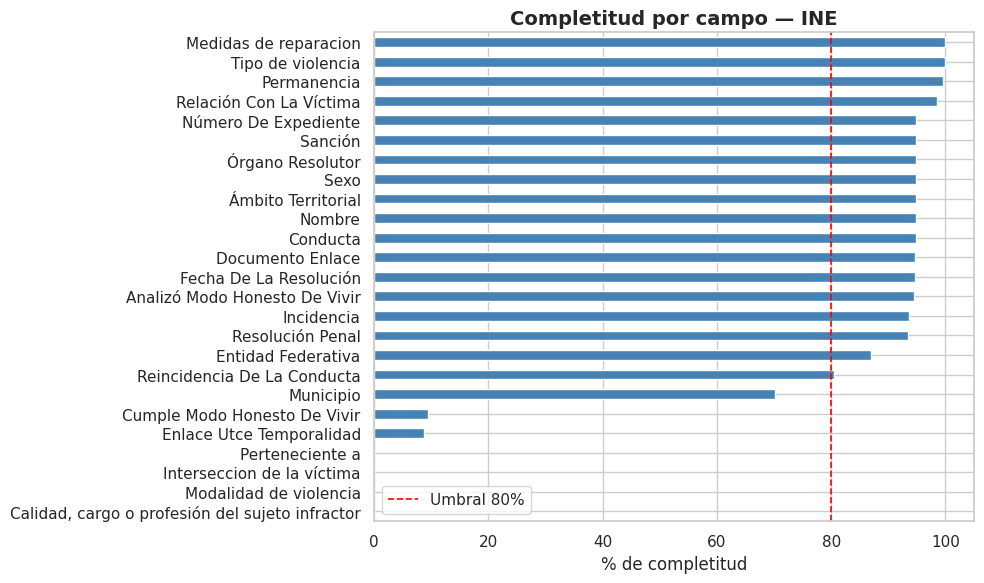

Columnas con <20% completitud (candidatas a descarte):
Calidad, cargo o profesión del sujeto infractor    0.000000
Perteneciente a                                    0.000000
Modalidad de violencia                             0.000000
Interseccion de la víctima                         0.000000
Enlace Utce Temporalidad                           8.679245
Cumple Modo Honesto De Vivir                       9.433962


In [6]:
# 1.1 Completitud INE
completitud_ine = (1 - df_ine_raw.isnull().mean()) * 100

fig, ax = plt.subplots(figsize=(10, 6))
completitud_ine.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Completitud por campo — INE', fontsize=14, fontweight='bold')
ax.set_xlabel('% de completitud')
ax.axvline(80, color='red', linestyle='--', linewidth=1.2, label='Umbral 80%')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Columnas con <20% completitud (candidatas a descarte):')
print(completitud_ine[completitud_ine < 20].sort_values().to_string())

In [7]:
# 1.2 Duplicados exactos por Nombre
dup_nombres = df_ine_raw[
    df_ine_raw['Nombre'].notna() &
    df_ine_raw['Nombre'].duplicated(keep=False)
]
print(f'Registros con nombres duplicados: {len(dup_nombres)}')
display(
    dup_nombres.sort_values('Nombre')
    [['Nombre','Número De Expediente','Conducta','Fecha De La Resolución']]
    .head(15)
)

Registros con nombres duplicados: 74


,Nombre,Número De Expediente,Conducta,Fecha De La Resolución
46,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-JDC-7/2025,Conductas encaminadas a entorpecer y demeritar su participación en el ejercicio del cargo de la ...,19/02/2025
47,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-25/2025,"Conductas desplegadas por el infractor al negar la contratación de un auxiliar, así como apoyo j...",10/06/2025
48,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-97/2025,Manifestaciones realizadas en publicaciones con la intención de disminuir las capacidades de la ...,25/02/2026
49,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-258/2025,"Actos que invisibilizan y discriminan a la quejosa, consistentes en la negativa de proporcionarl...",19/03/2026
55,ALEJANDRO SEVILLA TORRES,TEE-PES-60/2024,Publicaciones realizadas en la red social Facebook con la finalidad de desacredita y denigrar a ...,08/05/2025
56,ALEJANDRO SEVILLA TORRES,CLE-POS-022/2019,Publicaciones realizadas en la red social Facebook y en periódicos que utilizan estereotipos dir...,06/05/2021
103,CARLOS MARIO CORNELIO CORNELIO,PES/075/2021,Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para que ...,31/03/2022
104,CARLOS MARIO CORNELIO CORNELIO,PES/078/2021,Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para part...,28/02/2022
115,DANIEL LÓPEZ PLATAS,JDCI/48/2024,Acciones y omisiones que tuvieron como efecto directo el menoscabo del ejercicio del cargo de la...,03/12/2024
116,DANIEL LÓPEZ PLATAS,JDCI/73/2023,"Omisión de convocar a la víctima a sesiones de cabildo, obstaculizando su entrada a las oficinas...",20/10/2023


In [8]:
# 1.3 Campos con formatos mixtos
print('Permanencia (top 10 valores)\n')
print(df_ine_raw['Permanencia'].value_counts().head(10).to_string())
print()
print('Tipo de violencia (primeros 3 valores únicos)\n')
for v in df_ine_raw['Tipo de violencia'].dropna().unique()[:3]:
    print(' ', v[:120])
print()
print('Medidas de reparacion (primeros 3 valores únicos)\n')
for v in df_ine_raw['Medidas de reparacion'].dropna().unique()[:3]:
    print(' ', v[:120])

Permanencia (top 10 valores)

Permanencia
Indeterminada          26
07/10/2027             11
2026-10-11T00:00:00    10
15/07/2026              9
2027-03-25T00:00:00     8
2026-09-13T00:00:00     7
20/07/2028              7
2026-07-27T00:00:00     6
2028-04-27T00:00:00     6
2026-07-09T00:00:00     6

Tipo de violencia (primeros 3 valores únicos)

  tipo_conducta null="true"></tipo_conducta
  tipo_conducta type="Collection(Edm.String)">_x000d_
  <element>Simbólica</element>_x000d_
</tipo_conducta
  tipo_conducta type="Collection(Edm.String)">_x000d_
  <element>Simbólica</element>_x000d_
  <element>Psicológica</elemen

Medidas de reparacion (primeros 3 valores únicos)

  medidas_reparacion null="true"></medidas_reparacion
  medidas_reparacion type="Collection(Edm.String)">_x000d_
  <element>Medidas de satisfacción, medidas de restitución</ele
  medidas_reparacion type="Collection(Edm.String)">_x000d_
  <element>Medidas de no repetición</element>_x000d_
  <element


In [9]:
# 1.4 Distribuciones en campos categóricos
print('Campos categóricos con posibles inconsistencias (Top 7):')
for col in ['Sexo', 'Ambito Territorial', 'Sancion', 'Entidad Federativa']:
    col_real = next((c for c in df_ine_raw.columns if c.strip() == col or
                     unidecode(c.strip()) == unidecode(col)), None)
    if col_real:
        print(f'')
        conteo = df_ine_raw[col_real].value_counts(dropna=False)
        print(conteo.head(7).to_string())
        if len(conteo) > 7:
            print(f'... y {len(conteo) - 7} categorías más ocultas.')

Campos categóricos con posibles inconsistencias (Top 7):

Sexo
Hombre    412
Mujer      91
NaN        27

Ámbito Territorial
Municipal    340
Estatal       86
Nacional      77
NaN           27

Sanción
Ninguna                           228
Multa económica                   144
Amonestación pública              100
NaN                                27
Inscripción en el RNPS             25
Multa simbólica                     1
Multa, prisión y  amonestación      1
... y 4 categorías más ocultas.

Entidad Federativa
Oaxaca              143
Veracruz             72
NaN                  69
Chiapas              37
Tabasco              26
Estado de México     22
Guanajuato           20
... y 23 categorías más ocultas.


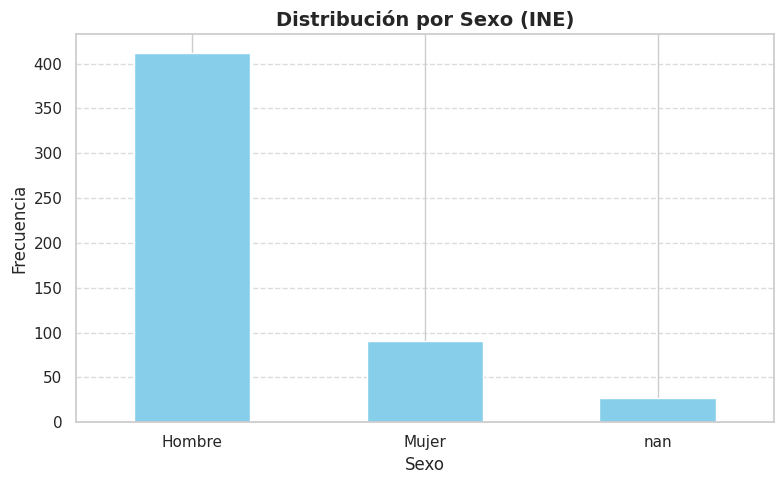

In [10]:
# Distribución: Sexo
plt.figure(figsize=(8, 5))
sexo_counts = df_ine_raw['Sexo'].value_counts(dropna=False)
sexo_counts.plot(kind='bar', color='skyblue')
plt.title('Distribución por Sexo (INE)', fontsize=14, fontweight='bold')
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

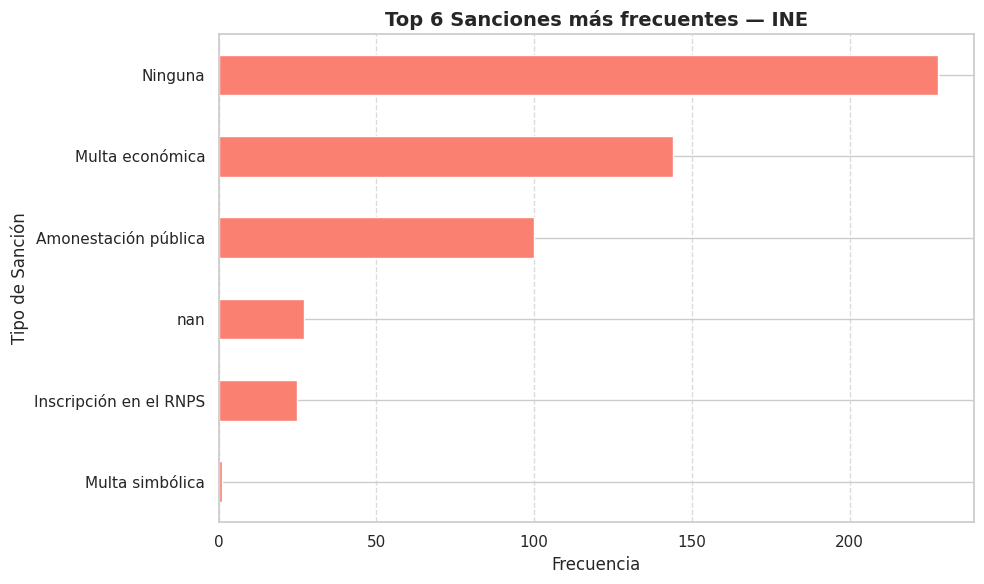

In [11]:
# Distribución: Sanción
plt.figure(figsize=(10, 6))
sancion_counts = df_ine_raw['Sanción'].value_counts(dropna=False).head(6)
sancion_counts.plot(kind='barh', color='salmon')
plt.title('Top 6 Sanciones más frecuentes — INE', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Tipo de Sanción', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

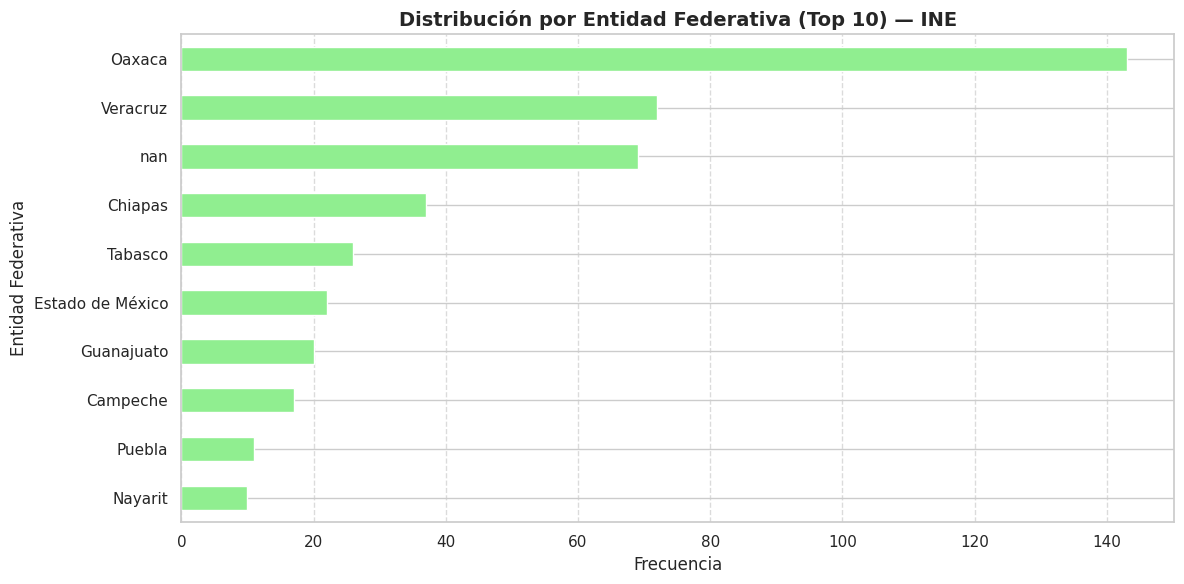

In [12]:
# Distribución: Entidad Federativa
plt.figure(figsize=(12, 6))
entidad_counts = df_ine_raw['Entidad Federativa'].value_counts(dropna=False).head(10)
entidad_counts.plot(kind='barh', color='lightgreen')
plt.title('Distribución por Entidad Federativa (Top 10) — INE', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Entidad Federativa', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Fecha mínima: 2020-11-09 00:00:00 | Fecha máxima: 2026-04-29 00:00:00
Fechas no parseables: 42


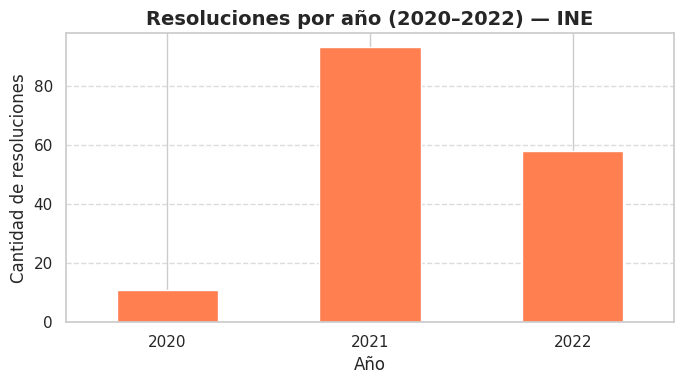

In [13]:
# 1.5 Oportunidad: resoluciones por año (2020-2022)
fechas = pd.to_datetime(df_ine_raw['Fecha De La Resolución'], dayfirst=True, errors='coerce')
print(f'Fecha mínima: {fechas.min()} | Fecha máxima: {fechas.max()}')
print(f'Fechas no parseables: {fechas.isna().sum()}')

conteo_anios = fechas.dropna().dt.year.value_counts().sort_index()
conteo_filtrado = conteo_anios.loc[2020:2022]

plt.figure(figsize=(7, 4))
conteo_filtrado.plot(kind='bar', color='coral')
plt.title('Resoluciones por año (2020–2022) — INE', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de resoluciones', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

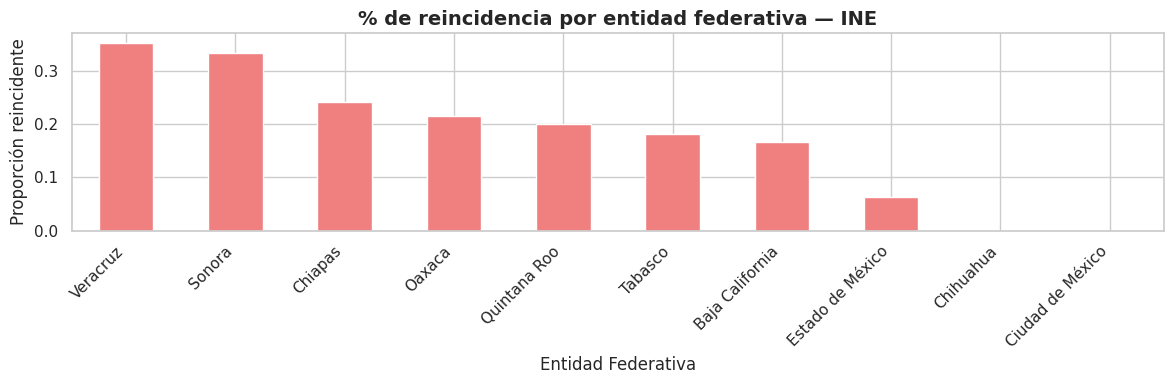

In [14]:
# 1.6 Reincidencia por entidad federativa
reincidencia = (
    df_ine_raw[df_ine_raw['Reincidencia De La Conducta'].notna()]
    .groupby('Entidad Federativa')['Reincidencia De La Conducta']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
col_si = [c for c in reincidencia.columns if str(c).strip().lower() in ('sí','si','yes','1','true')]
if col_si:
    reincidencia[col_si[0]].sort_values(ascending=False).head(10).plot(
        kind='bar', figsize=(12, 4), color='lightcoral', edgecolor='white'
    )
    plt.title('% de reincidencia por entidad federativa — INE', fontsize=14, fontweight='bold')
    plt.ylabel('Proporción reincidente')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Valores únicos en Reincidencia De La Conducta:', df_ine_raw['Reincidencia De La Conducta'].unique())

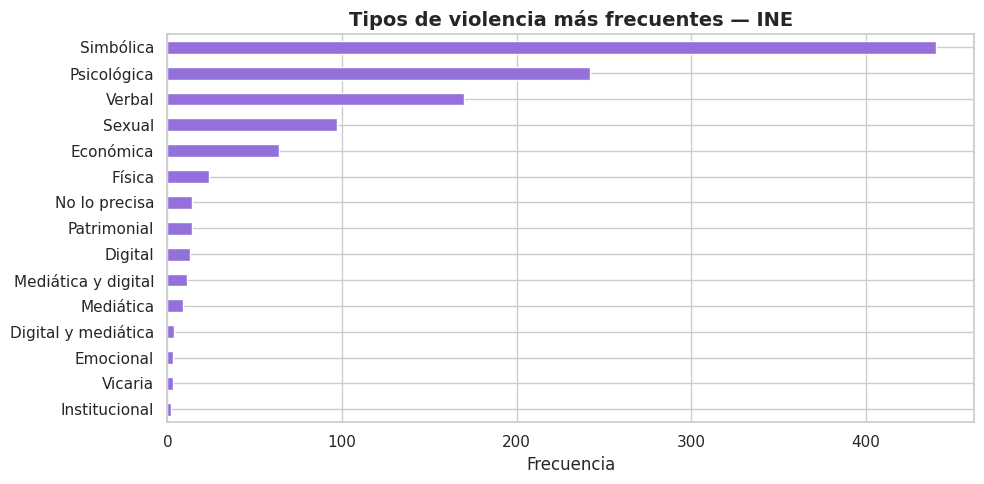

In [15]:
# 1.7 Tipos de violencia más frecuentes (tras parsear el XML)
tipos_raw = df_ine_raw['Tipo de violencia'].dropna()
todos_tipos = []
for val in tipos_raw:
    elementos = re.findall(r'<element>([^<]+)</element>', str(val))
    todos_tipos.extend([e.strip() for e in elementos])

if todos_tipos:
    pd.Series(todos_tipos).value_counts().head(15).sort_values().plot(
        kind='barh', figsize=(10, 5), color='mediumpurple', edgecolor='white'
    )
    plt.title('Tipos de violencia más frecuentes — INE', fontsize=14, fontweight='bold')
    plt.xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron etiquetas <element> en Tipo de violencia')

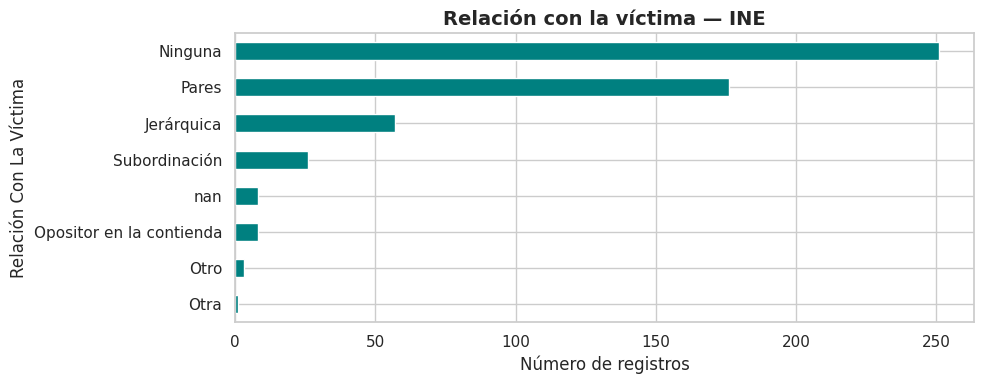

In [16]:
# 1.8 Relación víctima-agresor
fig, ax = plt.subplots(figsize=(10, 4))
(
    df_ine_raw['Relación Con La Víctima']
    .value_counts(dropna=False)
    .head(12)
    .sort_values()
    .plot(kind='barh', ax=ax, color='teal', edgecolor='white')
)
ax.set_title('Relación con la víctima — INE', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()

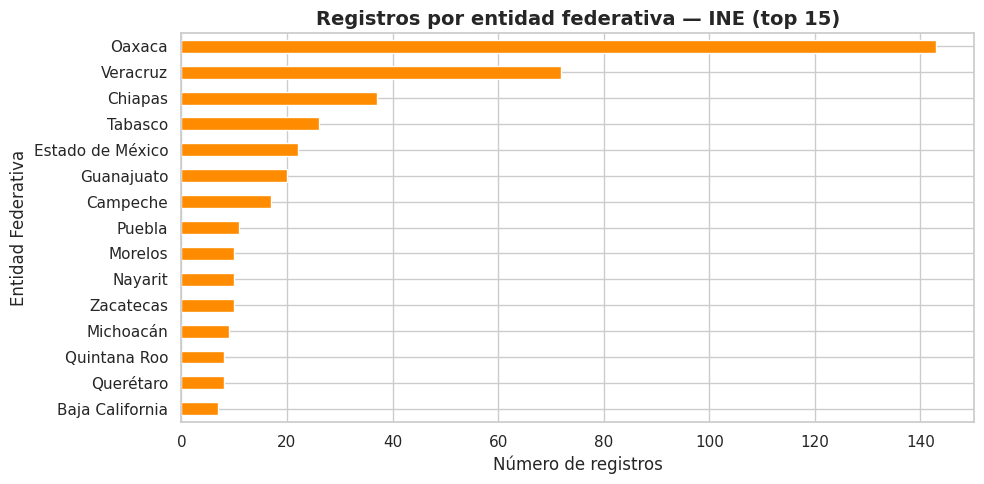

In [17]:
# 1.9 Agresores por entidad federativa (top 15)
fig, ax = plt.subplots(figsize=(10, 5))
(
    df_ine_raw['Entidad Federativa']
    .value_counts()
    .head(15)
    .sort_values()
    .plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
)
ax.set_title('Registros por entidad federativa — INE (top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()

### 1.2 Base BANAVIM

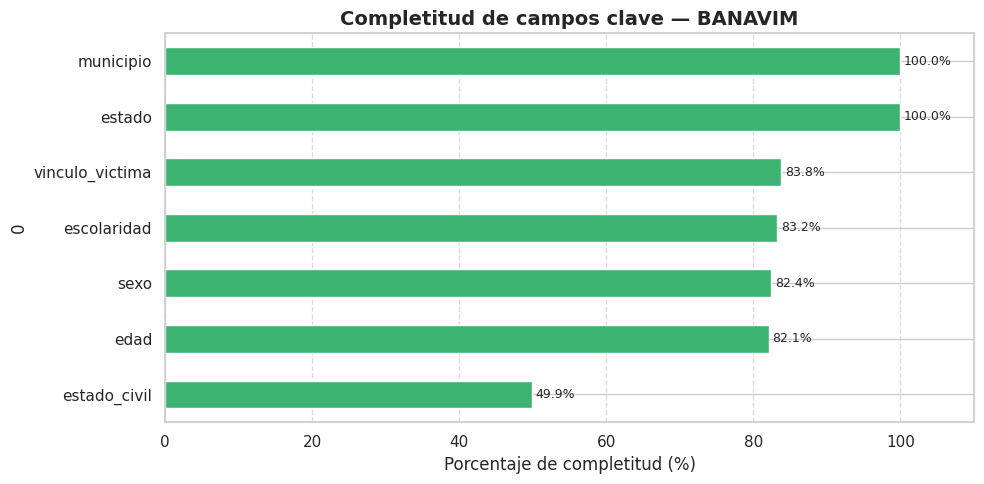

In [18]:
# Concatenación cruda para perfilado (columnas originales, antes de limpieza)
bv_raw = pd.concat([bv_2020, bv_2021, bv_2022], ignore_index=True)

# 1.10 Completitud de campos clave en BANAVIM (nombres originales del Excel)
campos_clave_raw = [
    'Sexo', 'Edad del Agresor', 'Escolaridad', 'Estado Civil',
    'Estado donde reside', 'Municipio donde reside',
    'Relación o vículo con la víctima'
]
etiquetas = [
    'sexo', 'edad', 'escolaridad', 'estado_civil',
    'estado', 'municipio', 'vinculo_victima'
]
completitud_bv = (
    (1 - bv_raw[campos_clave_raw].isnull().mean())
    .mul(100)
    .rename(dict(zip(campos_clave_raw, etiquetas)))
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
completitud_bv.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Completitud de campos clave — BANAVIM', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje de completitud (%)')
ax.set_xlim(0, 110)
ax.grid(axis='x', linestyle='--', alpha=0.7)
for bar in ax.patches:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# 1.11 Duplicados por Identificador Único
dup_id = bv_raw[bv_raw['Identificador Único'].notna() & bv_raw['Identificador Único'].duplicated(keep=False)]
print(f'Total de registros en BANAVIM: {len(bv_raw):,}')
print(f'Registros con Identificador Único duplicado: {len(dup_id):,} ({len(dup_id)/len(bv_raw)*100:.1f}%)')
display(
    dup_id[['Identificador Único', 'Sexo', 'Estado donde reside', 'Relación o vículo con la víctima', 'año_base']]
    .sort_values('Identificador Único')
    .head(10)
)

Total de registros en BANAVIM: 806,092
Registros con Identificador Único duplicado: 78,491 (9.7%)


,Identificador Único,Sexo,Estado donde reside,Relación o vículo con la víctima,año_base
265795,0128800103-1,NaN,Aguascalientes,NaN,2021
265794,0128800103-1,NaN,Aguascalientes,NaN,2021
265804,0128800112-1,Hombre,Aguascalientes,CÃ³nyuge o pareja,2021
265805,0128800112-1,Hombre,Aguascalientes,CÃ³nyuge o pareja,2021
265812,0128800119-1,Hombre,Aguascalientes,Hijo(a),2021
265813,0128800119-1,Hombre,Aguascalientes,CÃ³nyuge o pareja,2021
265814,0128800120-1,Hombre,Aguascalientes,Hermano(a),2021
265815,0128800120-1,NaN,Aguascalientes,NaN,2021
265819,0128800124-1,NaN,Aguascalientes,NaN,2021
265820,0128800124-1,Hombre,Aguascalientes,Madre o padre,2021


In [20]:
# 1.12 Campos con formatos mixtos / mojibake
PATRON_MOJIBAKE = r'[ÃÂ�]'
cols_texto_raw = bv_raw.select_dtypes(include='object').columns.tolist()
mojibake_res = [
    {'Campo': col, 'Registros con mojibake': bv_raw[col].astype(str).str.contains(PATRON_MOJIBAKE, regex=True, na=False).sum()}
    for col in cols_texto_raw
]
mojibake_df = pd.DataFrame(mojibake_res).query('`Registros con mojibake` > 0').sort_values('Registros con mojibake', ascending=False)
print('\nCampos con problemas de codificación (mojibake):')
display(mojibake_df.reset_index(drop=True))


Campos con problemas de codificación (mojibake):


,Campo,Registros con mojibake
0,Relación o vículo con la víctima,305694
1,Municipio donde reside,296001
2,Estado donde reside,213569
3,Estado Civil,61713
4,Escolaridad,10943
5,Cual Droga,1634



Campos categóricos con posibles inconsistencias (Top 7):

Escolaridad:
Escolaridad
No identificado    237857
Secundaria         171258
NaN                135372
Preparatoria        87142
Primaria            79091
Licenciatura        48265
Ninguna             22517

Estado Civil:
Estado Civil
NaN                404073
Casado             126165
No identificado     80570
Soltero             75621
UniÃ³n libre        61713
Concubinato         25706
Separado            17533

Conoce al Agresor:
Conoce al Agresor
SI     664302
NO     141786
NaN         4

Posee_algun tipo de arma:
Posee_algun tipo de arma
SE DESCONOCE    377500
NO              375366
SI               52546
NaN                680


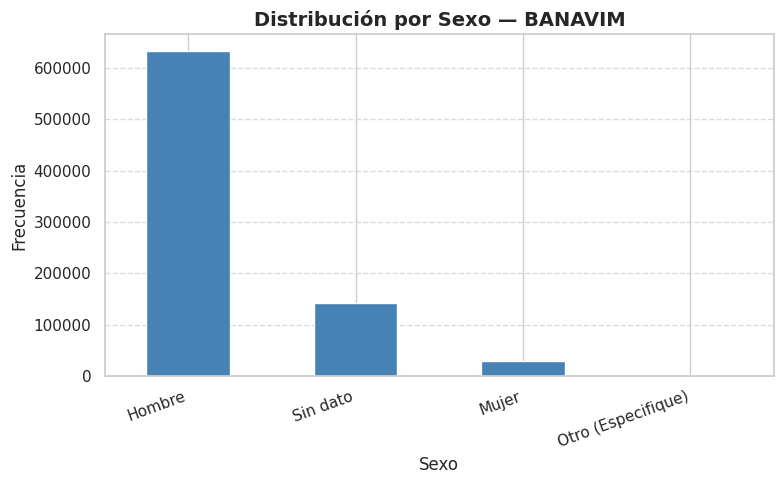

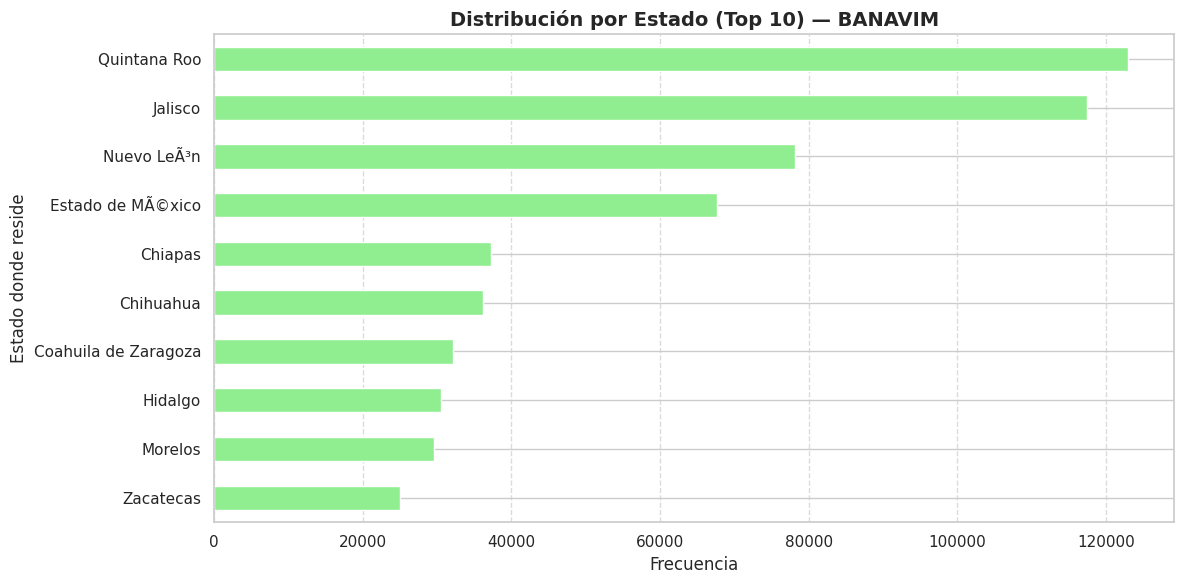

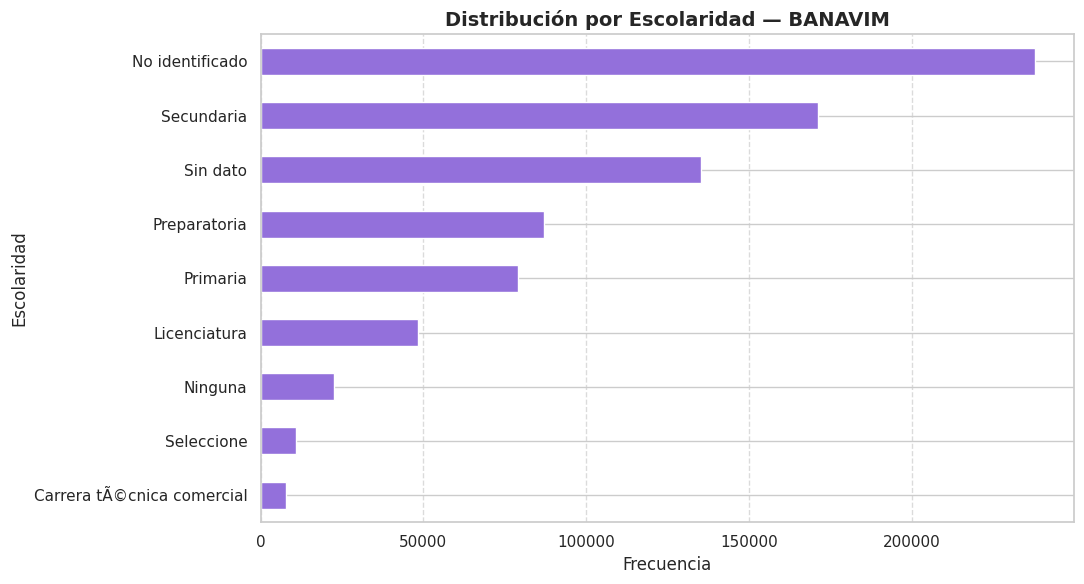

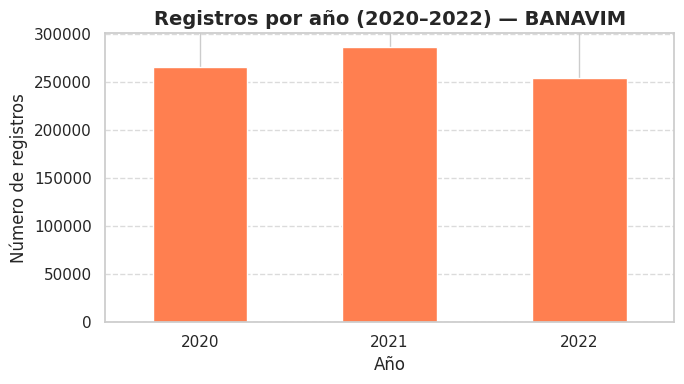

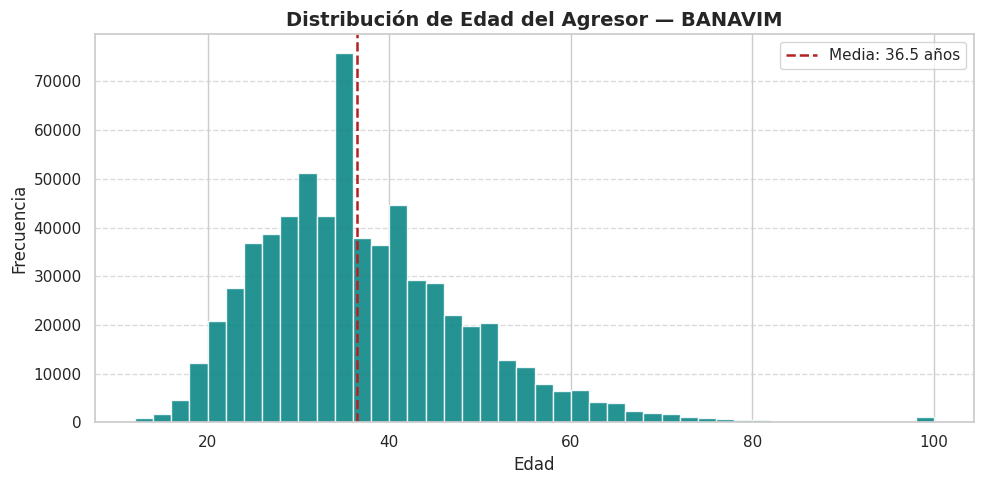

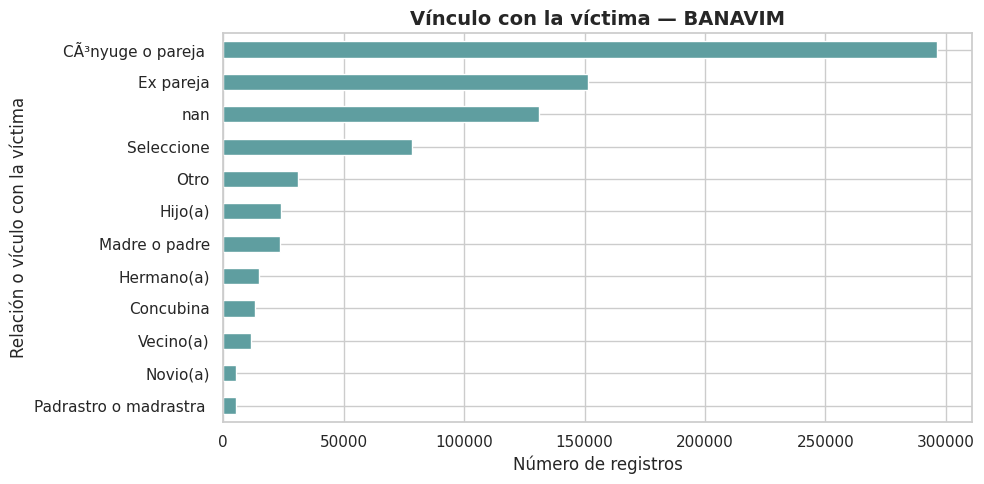

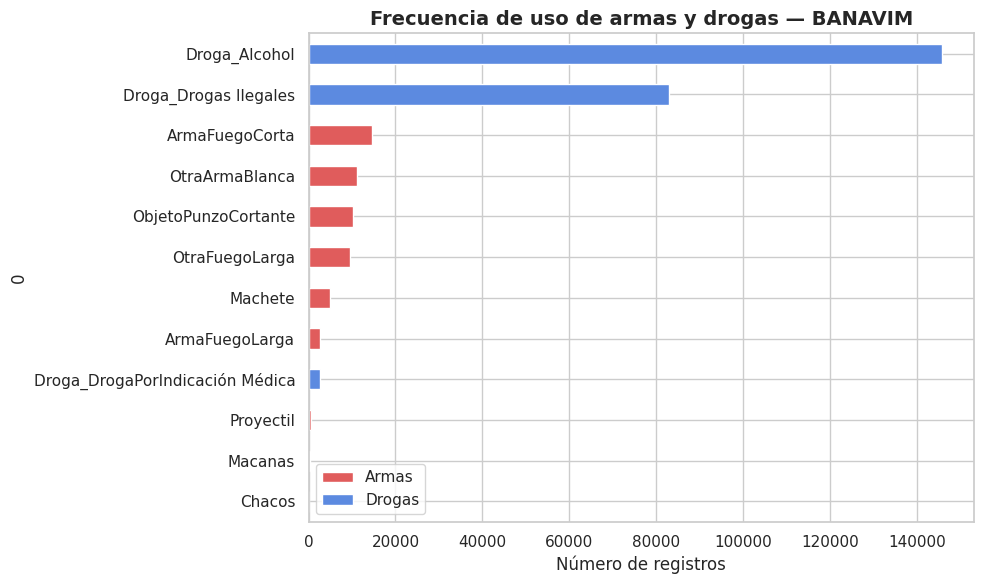

In [21]:
# 1.13 Distribuciones categóricas (texto)
print('\nCampos categóricos con posibles inconsistencias (Top 7):')
for col in ['Escolaridad', 'Estado Civil', 'Conoce al Agresor', 'Posee_algun tipo de arma']:
    print(f'\n{col}:')
    print(bv_raw[col].value_counts(dropna=False).head(7).to_string())

# Distribución: Sexo
plt.figure(figsize=(8, 5))
sc = bv_raw['Sexo'].value_counts(dropna=False)
sc.index = sc.index.fillna('Sin dato')
sc.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución por Sexo — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribución: Estado (Top 10)
plt.figure(figsize=(12, 6))
bv_raw['Estado donde reside'].value_counts(dropna=False).head(10).plot(
    kind='barh', color='lightgreen', edgecolor='white')
plt.title('Distribución por Estado (Top 10) — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribución: Escolaridad
plt.figure(figsize=(11, 6))
ec = bv_raw['Escolaridad'].value_counts(dropna=False).head(9)
ec.index = ec.index.fillna('Sin dato')
ec.sort_values().plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.title('Distribución por Escolaridad — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1.14 Registros por año
plt.figure(figsize=(7, 4))
bv_raw['año_base'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Registros por año (2020–2022) — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de registros', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1.15 Distribución de edad
plt.figure(figsize=(10, 5))
edad_num = pd.to_numeric(bv_raw['Edad del Agresor'], errors='coerce')
edad_valida = edad_num[(edad_num >= 12) & (edad_num <= 100)]
plt.hist(edad_valida, bins=44, color='teal', edgecolor='white', alpha=0.85)
plt.axvline(edad_valida.mean(), color='firebrick', linestyle='--', linewidth=1.8,
            label=f'Media: {edad_valida.mean():.1f} años')
plt.title('Distribución de Edad del Agresor — BANAVIM', fontsize=14, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1.16 Vínculo con la víctima
fig, ax = plt.subplots(figsize=(10, 5))
(
    bv_raw['Relación o vículo con la víctima']
    .value_counts(dropna=False)
    .head(12)
    .sort_values()
    .plot(kind='barh', ax=ax, color='cadetblue', edgecolor='white')
)
ax.set_title('Vínculo con la víctima — BANAVIM', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros', fontsize=12)
plt.tight_layout()
plt.show()

# 1.17 Uso de armas y drogas (flags binarios)
_ARMAS  = ['Chacos','Macanas','OtraArmaBlanca','ObjetoPunzoCortante',
           'Machete','Proyectil','ArmaFuegoCorta','ArmaFuegoLarga','OtraFuegoLarga']
_DROGAS = ['Droga_Alcohol','Droga_DrogaPorIndicación Médica','Droga_Drogas Ilegales']
uso = (
    bv_raw[_ARMAS + _DROGAS]
    .apply(pd.to_numeric, errors='coerce')
    .sum()
    .sort_values(ascending=True)
)
_colors = ['#5c8ae0' if c in _DROGAS else '#e05c5c' for c in uso.index]
fig, ax = plt.subplots(figsize=(10, 6))
uso.plot(kind='barh', ax=ax, color=_colors, edgecolor='white')
ax.set_title('Frecuencia de uso de armas y drogas — BANAVIM', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros', fontsize=12)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e05c5c', label='Armas'), Patch(facecolor='#5c8ae0', label='Drogas')], fontsize=11)
plt.tight_layout()
plt.show()